In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/people-detection/README.dataset.txt
/kaggle/input/people-detection/valid/valid/2008_002129_jpg.rf.eabffaccdb1ccd62cc23ad10cb20b72d.jpg
/kaggle/input/people-detection/valid/valid/photo-1533906395497-33f8df24d687_jpg.rf.c86a32ffdcdd70ff300d00d052a32c81.jpg
/kaggle/input/people-detection/valid/valid/2010_001682_jpg.rf.e9de891b3d1faa5a447c7f07e9801daf.jpg
/kaggle/input/people-detection/valid/valid/20230127_182724_mp4-124_jpg.rf.7fff3ea2bef719b6ed090e6f66f5f6f4.jpg
/kaggle/input/people-detection/valid/valid/000230_jpg.rf.eba710b00812dbda1578cd01a496be05.jpg
/kaggle/input/people-detection/valid/valid/1323_person_jpg.rf.e63b2a7ae1237f5b66805ee69c3e7214.jpg
/kaggle/input/people-detection/valid/valid/-1_-Av513706663-P1-_mp4-22_jpg.rf.7bdce57b726ce6391a5e982a2933b4fc.jpg
/kaggle/input/people-detection/valid/valid/URH4HHQBTXAX_jpg.rf.dd526707b4b2ac53247ecb69f39ffce9.jpg
/kaggle/input/people-detection/valid/valid/000097_jpg.rf.9417a80fe19cfae9be60d40a1ca330b4.jpg
/kaggle/input/people

In [2]:
# Install with compatible numpy first
!pip install -q 'numpy<2.0' 'scipy<1.14'

# Then install ultralytics
!pip install -q ultralytics

# Restart kernel here, then run:
import torch 
from torch import nn
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from collections import Counter
import os
import random
from PIL import Image, ImageDraw
from ultralytics import YOLO
import ultralytics

print("✅ NumPy version:", np.__version__)
print("✅ Ultralytics version:", ultralytics.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 48.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.2 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but y

In [3]:
img = Image.open("/kaggle/input/people-detection/train/train/-Blvd-Antonio-l-Rodriguez-188-Conference-Room-Member-Engagement-1-1440x810_jpg.rf.f6b8f36c7f950c051dae7c256e4300d4.jpg")
# Image.open and then pass the dir of the image to view the image

(-0.5, 609.5, 609.5, -0.5)

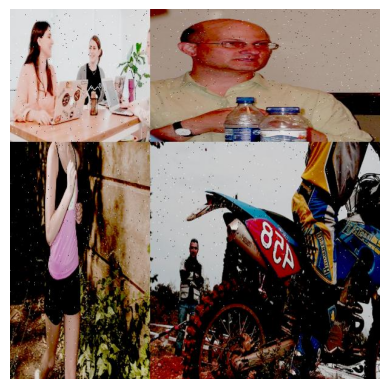

In [4]:
plt.imshow(img)
plt.axis("off") # Axis 

In [5]:
def count_files_by_extension(directory_path):
    extension_counts = Counter()
    for root, _, files in os.walk(directory_path):
        for file in files:
            _, ext = os.path.splitext(file)
            
            if ext:  
                extension_counts[ext.lower()] += 1  

            if file.endswith(".csv"):
                print("CSV Path:", os.path.join(root, file))
                
    return extension_counts

target_directory = '/kaggle/input/people-detection/train/train' 
file_counts = count_files_by_extension(target_directory)

for ext, count in file_counts.items():
    print(f"Extension: {ext}, Count: {count}")

CSV Path: /kaggle/input/people-detection/train/train/_annotations.csv
Extension: .jpg, Count: 15210
Extension: .csv, Count: 1


In [6]:
df = pd.read_csv("/kaggle/input/people-detection/train/train/_annotations.csv")

df

,filename,width,height,class,xmin,ymin,xmax,ymax
0,2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...,500,375,person,219,98,269,283
1,2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...,500,375,person,114,124,155,263
2,2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...,500,375,person,43,139,98,340
3,004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...,500,333,person,145,118,229,333
4,004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...,500,333,person,285,105,349,329
...,...,...,...,...,...,...,...,...
100077,2008_007145_jpg.rf.99fc120cdee10b38fe50fe80989...,4410,3308,person,1957,1753,2022,1847
100078,2008_007145_jpg.rf.99fc120cdee10b38fe50fe80989...,4410,3308,person,2014,1753,2099,1854
100079,2008_007145_jpg.rf.99fc120cdee10b38fe50fe80989...,4410,3308,person,1519,1805,1588,1920
100080,2008_007145_jpg.rf.99fc120cdee10b38fe50fe80989...,4410,3308,person,1588,1809,1657,1901


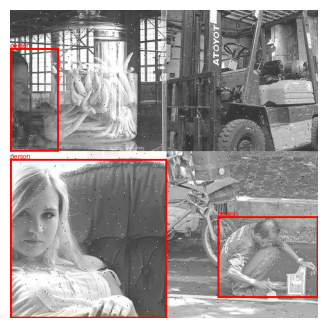

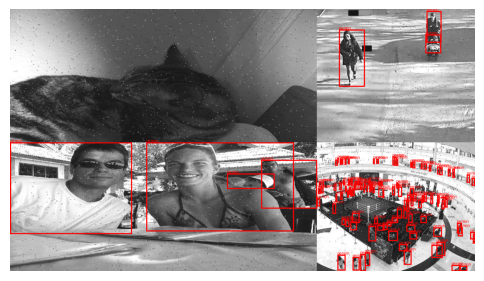

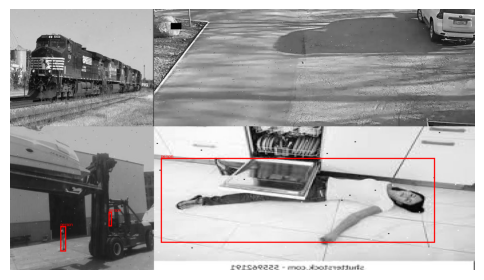

In [7]:
img_dir = "/kaggle/input/people-detection/train/train" 
sample_images = df['filename'].sample(3).values # this will get 3 random samples from the csv file 

# looping through every random sample and check if the file that is that dataset is found in the set of training images we have so 
for img_name in sample_images:
    rows = df[df['filename'] == img_name]
    img_path = os.path.join(img_dir, img_name)
    
    try:
        img = Image.open(img_path).convert("RGB")
    except:
        print(f"Could not load {img_path}")
        continue

    draw = ImageDraw.Draw(img) 
    for _, row in rows.iterrows():
        box = [row['xmin'], row['ymin'], row['xmax'], row['ymax']] # getting the numbers from the dataset
        draw.rectangle(box, outline="red", width=3) # draw the rec and passing the color and width and the box we made above
        draw.text((box[0], box[1] - 10), row['class'], fill="red")

    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [8]:
image_paths = [os.path.join(img_dir, f) for f in df["filename"].unique()]
test_dir = [os.path.join("/kaggle/input/people-detection/test/test", f) for f in df["filename"].unique()]

Might not need the dataset loader

In [9]:
from pathlib import Path
import shutil
from tqdm import tqdm
import os, sys, json, random
from IPython.display import FileLink, display


In [10]:
# Check if CUDA is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"✅ Using device: {device}")

if device == 'cuda':
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

# Load model with detected device
model = YOLO('yolov8n.pt').to(device)

✅ Using device: cuda
✅ GPU: Tesla P100-PCIE-16GB


In [11]:
CSV_PATH = "/kaggle/input/people-detection/train/train/_annotations.csv"
IMAGES_SRC_DIR = "/kaggle/input/people-detection/train/train"  # where the images actually live

df = pd.read_csv(CSV_PATH)
print(df.head())
print("\nColumns:", list(df.columns))
print("\nUnique classes:", df['class'].unique())
print("\n# rows:", len(df), "| # unique images:", df['filename'].nunique())

                                            filename  width  height   class  \
0  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
1  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
2  2008_003132_jpg.rf.92f6223defec4f57f2d7b9cfa28...    500     375  person   
3  004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...    500     333  person   
4  004574_jpg.rf.7c8cea69d7be45f58febcede26ef0c6e...    500     333  person   

   xmin  ymin  xmax  ymax  
0   219    98   269   283  
1   114   124   155   263  
2    43   139    98   340  
3   145   118   229   333  
4   285   105   349   329  

Columns: ['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax']

Unique classes: ['person']

# rows: 100082 | # unique images: 13278


In [12]:
# Output (working) dataset root
ROOT = Path("/kaggle/working/people_yolo")
for p in [
    ROOT/"images/train", ROOT/"images/val",
    ROOT/"labels/train", ROOT/"labels/val"
]:
    p.mkdir(parents=True, exist_ok=True)

print("Dataset root:", ROOT.resolve())

Dataset root: /kaggle/working/people_yolo


In [13]:
# Deterministic split
rng = np.random.default_rng(42)
unique_imgs = df['filename'].unique()
rng.shuffle(unique_imgs)

val_ratio = 0.2
val_count = int(len(unique_imgs) * val_ratio)
val_set = set(unique_imgs[:val_count])
train_set = set(unique_imgs[val_count:])

len(unique_imgs), len(train_set), len(val_set)

(13278, 10623, 2655)

In [14]:
def voc_to_yolo_xywh_norm(xmin, ymin, xmax, ymax, img_w, img_h):
    # centers
    x_c = (xmin + xmax) / 2.0
    y_c = (ymin + ymax) / 2.0
    # width/height
    w = xmax - xmin
    h = ymax - ymin
    # normalize
    return x_c / img_w, y_c / img_h, w / img_w, h / img_h

In [15]:
# We’ll group by filename to write one .txt per image
# Your CSV already has image width/height per row; we’ll use the first row per filename.
missing_images = []
label_counts = {"train": 0, "val": 0}

# Pre-scan existing image files to avoid repeated disk hits
# We try both common extensions just in case (csv usually lists the exact filename though).
def resolve_image_path(images_dir, name):
    p = Path(images_dir) / name
    if p.exists():
        return p
    # If filename has dots like ".jpg.rf.xxxx", we still trust it as-is. If not found, try jpg/png fallback:
    candidates = [
        p.with_suffix(".jpg"),
        p.with_suffix(".jpeg"),
        p.with_suffix(".png"),
        p.with_suffix(".JPG"),
        p.with_suffix(".PNG"),
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

for filename, group in tqdm(df.groupby("filename"), total=df['filename'].nunique()):
    subset = "val" if filename in val_set else "train"

    # Resolve input image
    src_img = resolve_image_path(IMAGES_SRC_DIR, filename)
    if src_img is None:
        missing_images.append(filename)
        continue

    # Copy image to working set
    dst_img = ROOT / "images" / subset / src_img.name
    if not dst_img.exists():
        shutil.copy2(src_img, dst_img)

    # Build label path (same stem, .txt)
    dst_lbl = ROOT / "labels" / subset / (dst_img.stem + ".txt")

    # Use first record to get image width/height (they should be identical per image)
    img_w = int(group.iloc[0]["width"])
    img_h = int(group.iloc[0]["height"])

    # Write all boxes for this image
    lines = []
    for _, r in group.iterrows():
        xmin, ymin, xmax, ymax = float(r["xmin"]), float(r["ymin"]), float(r["xmax"]), float(r["ymax"])
        x_c, y_c, w, h = voc_to_yolo_xywh_norm(xmin, ymin, xmax, ymax, img_w, img_h)
        # class_id = 0 (only person)
        # Limit precision to 6 decimals to keep files compact
        lines.append(f"0 {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

    with open(dst_lbl, "w") as f:
        f.write("\n".join(lines))

    label_counts[subset] += len(lines)

print("✅ Label generation complete.")
print("Train labels:", label_counts["train"], "| Val labels:", label_counts["val"])
if missing_images:
    print("⚠️ Missing", len(missing_images), "images that were referenced in CSV but not found in", IMAGES_SRC_DIR)
    print("Example:", missing_images[:5])

100%|██████████| 13278/13278 [01:29<00:00, 148.75it/s]

✅ Label generation complete.
Train labels: 79098 | Val labels: 20984


In [16]:
YAML_PATH = "/kaggle/working/people.yaml"

yaml_text = f"""# Auto-generated for People detection (one class)
train: {ROOT}/images/train
val: {ROOT}/images/val

nc: 1
names: ['person']
"""

with open(YAML_PATH, "w") as f:
    f.write(yaml_text)

print("Wrote:", YAML_PATH)
print("----")
print(yaml_text)

Wrote: /kaggle/working/people.yaml
----
# Auto-generated for People detection (one class)
train: /kaggle/working/people_yolo/images/train
val: /kaggle/working/people_yolo/images/val

nc: 1
names: ['person']



In [17]:
from itertools import islice

sample_txts = list(islice((ROOT/"labels/train").glob("*.txt"), 5))
for p in sample_txts:
    print("==>", p.name)
    print(p.read_text().splitlines()[:3], "...")  # show first lines only

==> 000142_jpg.rf.ec08786bb63aa446e68fc93fa48d00cd.txt
['0 0.328906 0.791667 0.055729 0.212963', '0 0.735677 0.647222 0.049479 0.205556', '0 0.709896 0.539352 0.046875 0.217593'] ...
==> 2008_004477_jpg.rf.bb748f5160a277ef685f01dbd7016990.txt
['0 0.681117 0.269376 0.166489 0.270321', '0 0.100798 0.722590 0.051596 0.154064', '0 0.042287 0.686673 0.051596 0.165406'] ...
==> 2008_000878_jpg.rf.7cc56bed05b7bd9c09546a00818020d5.txt
['0 0.353000 0.441953 0.166000 0.319261'] ...
==> 2008_003542_jpg.rf.989faed802a5c01cfefaa85accfb9027.txt
['0 0.267206 0.174089 0.522267 0.348178', '0 0.403846 0.733806 0.269231 0.532389', '0 0.264170 0.667004 0.107287 0.269231'] ...
==> 002007_jpg.rf.7c70dc610cbd00414164e59a20f5b081.txt
['0 0.303000 0.564371 0.086000 0.284431', '0 0.409000 0.642216 0.210000 0.302395'] ...


In [18]:
model = YOLO('yolov8n.pt').to('cuda:0' if torch.cuda.is_available() else 'cpu')

In [19]:

# Tip: adjust epochs/batch/imgsz to your GPU memory & dataset size
results = model.train(
    data=YAML_PATH,
    epochs=15,
    imgsz=640,
    batch=16,
    lr0=0.01,        
    patience=20,     # early stop if no improvement
    device=0,        # use GPU
)

print("Training complete. Best run dir:", model.trainer.best)

Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/people.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True,

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2655      20961      0.818      0.668       0.75      0.492
Speed: 0.1ms preprocess, 1.4ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/train
Training complete. Best run dir: /kaggle/working/runs/detect/train/weights/best.pt


In [20]:
metrics = model.val()  # uses the last-trained weights by default
metrics.results_dict  # show summarized metrics

Ultralytics 8.3.221 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1255.5±314.3 MB/s, size: 47.7 KB)
val: Scanning /kaggle/working/people_yolo/labels/val.cache... 2655 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2655/2655 4.8Mit/s 0.0s
val: /kaggle/working/people_yolo/images/val/2007_000187_jpg.rf.6072bb3923494a7afb8648ba483324fd.jpg: 23 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 166/166 9.1it/s 18.2s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       2655      20961      0.819      0.668      0.749      0.492
Speed: 0.8ms preprocess, 1.9ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


{'metrics/precision(B)': 0.8187959498710037,
 'metrics/recall(B)': 0.6676317671508967,
 'metrics/mAP50(B)': 0.7492640549492833,
 'metrics/mAP50-95(B)': 0.49248677267271956,
 'fitness': 0.49248677267271956}

In [21]:
pred_dir = "/kaggle/working/preds"
os.makedirs(pred_dir, exist_ok=True)

# Run inference on a handful of val images
val_imgs = list((ROOT/"images/val").glob("*"))[:16]
if val_imgs:
    model.predict(source=[str(p) for p in val_imgs], conf=0.25, save=True, project=pred_dir, name="people_preds", imgsz=640)
    print("Predictions saved under:", f"{pred_dir}/people_preds")
else:
    print("No val images found for quick prediction preview.")


0: 640x640 12 persons, 2.4ms
1: 640x640 11 persons, 2.4ms
2: 640x640 3 persons, 2.4ms
3: 640x640 8 persons, 2.4ms
4: 640x640 12 persons, 2.4ms
5: 640x640 5 persons, 2.4ms
6: 640x640 2 persons, 2.4ms
7: 640x640 3 persons, 2.4ms
8: 640x640 4 persons, 2.4ms
9: 640x640 1 person, 2.4ms
10: 640x640 4 persons, 2.4ms
11: 640x640 4 persons, 2.4ms
12: 640x640 3 persons, 2.4ms
13: 640x640 4 persons, 2.4ms
14: 640x640 4 persons, 2.4ms
15: 640x640 1 person, 2.4ms
Speed: 2.1ms preprocess, 2.4ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/preds/people_preds
Predictions saved under: /kaggle/working/preds/people_preds


In [22]:
# Locate best.pt
best = Path("runs/detect")  # Ultralytics default project
best_ckpts = sorted(best.glob("*/weights/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
if best_ckpts:
    best_path = best_ckpts[0]
    print("Best weights:", best_path)
    display(FileLink(best_path))
else:
    print("❌ Could not find best.pt. Check your training cell logs.")

Best weights: runs/detect/train/weights/best.pt


/kaggle/working/runs/detect/train/weights/best.pt